# B9FT102_2425_TMD2 - INFORMATION & CYBERSECURITY MANAGEMENT

# LOADING DATA

Dataset: https://www.kaggle.com/datasets/hassan06/nslkdd \
Data dictionary for this dataset: https://medium.com/towards-data-science/a-deeper-dive-into-the-nsl-kdd-data-set-15c753364657

In [18]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff
import sqlalchemy as sa
import urllib
import pyodbc
from sklearn import preprocessing
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, precision_score, recall_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC

In [19]:
#Read train and test data in CSV files without column names
train_df = pd.read_csv(r'..\Submission\Datasets\Datasets of ML models\KDDTrain+.txt\KDDTrain+.txt')
test_df = pd.read_csv(r'..\Submission\Datasets\Datasets of ML models\KDDTest+.txt\KDDTest+.txt')

In [20]:
#See first 5 rows of train dataset
train_df.head()

,0,tcp,ftp_data,SF,491,0.1,0.2,0.3,0.4,0.5,...,0.17,0.03,0.17.1,0.00.6,0.00.7,0.00.8,0.05,0.00.9,normal,20
0,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune,21


In [21]:
#See first 5 rows of test dataset
test_df.head()

,0,tcp,private,REJ,0.1,0.2,0.3,0.4,0.5,0.6,...,0.04.1,0.06.1,0.00.3,0.00.4,0.00.5,0.00.6,1.00.2,1.00.3,neptune,21
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.00,0.0,1.00,1.00,neptune,21
1,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.00,0.0,0.00,0.00,normal,21
2,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.00,0.0,0.00,0.00,saint,15
3,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.00,0.0,0.83,0.71,mscan,11
4,0,tcp,http,SF,267,14515,0,0,0,0,...,1.00,0.00,0.01,0.03,0.01,0.0,0.00,0.00,normal,21


In [22]:
# Check size of training data and testing data
print(train_df.shape)
print(test_df.shape)

(125972, 43)
(22543, 43)


In [23]:
#Create a function to add columns names from ARFF files into train and test dataframes
def add_column_names(path,df_1):
    data = arff.loadarff(path)
    df = pd.DataFrame(data[0])
    column_name = list(df.columns)
    column_name.append('level')
    df_1.columns = column_name

In [24]:
#Apply the function
train_path = r'..\Submission\Datasets\Datasets of ML models\KDDTrain+.arff\KDDTrain+.arff'
test_path = r'..\Submission\Datasets\Datasets of ML models\KDDTest+.arff\KDDTest+.arff'
add_column_names(train_path, train_df)
add_column_names(test_path, test_df)

In [25]:
#Combine train and test data for storage
raw_data = pd.concat([train_df, test_df])
raw_data

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,level
0,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.00,1.00,neptune,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22538,0,tcp,smtp,SF,794,333,0,0,0,0,...,0.72,0.06,0.01,0.01,0.01,0.00,0.00,0.00,normal,21
22539,0,tcp,http,SF,317,938,0,0,0,0,...,1.00,0.00,0.01,0.01,0.01,0.00,0.00,0.00,normal,21
22540,0,tcp,http,SF,54540,8314,0,0,0,2,...,1.00,0.00,0.00,0.00,0.00,0.00,0.07,0.07,back,15
22541,0,udp,domain_u,SF,42,42,0,0,0,0,...,0.99,0.01,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [26]:
'''
#Store full raw data in database
connection_string = (
    "Driver={ODBC Driver 17 for SQL Server};"
    "Server=ANHTRINH;"
    "Database=cybersecurity;"
    "Trusted_Connection=yes;"
)
quoted = urllib.parse.quote_plus(connection_string)
engine = sa.create_engine(f'mssql+pyodbc:///?odbc_connect={quoted}')
with engine.connect() as cnn:
    raw_data.to_sql('Traffic',con=cnn, if_exists='replace', index=False)'
'''

'\n#Store full raw data in database\nconnection_string = (\n    "Driver={ODBC Driver 17 for SQL Server};"\n    "Server=ANHTRINH;"\n    "Database=cybersecurity;"\n    "Trusted_Connection=yes;"\n)\nquoted = urllib.parse.quote_plus(connection_string)\nengine = sa.create_engine(f\'mssql+pyodbc:///?odbc_connect={quoted}\')\nwith engine.connect() as cnn:\n    raw_data.to_sql(\'Traffic\',con=cnn, if_exists=\'replace\', index=False)\'\n'

In [27]:
# Check types of train data
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125972 entries, 0 to 125971
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125972 non-null  int64  
 1   protocol_type                125972 non-null  object 
 2   service                      125972 non-null  object 
 3   flag                         125972 non-null  object 
 4   src_bytes                    125972 non-null  int64  
 5   dst_bytes                    125972 non-null  int64  
 6   land                         125972 non-null  int64  
 7   wrong_fragment               125972 non-null  int64  
 8   urgent                       125972 non-null  int64  
 9   hot                          125972 non-null  int64  
 10  num_failed_logins            125972 non-null  int64  
 11  logged_in                    125972 non-null  int64  
 12  num_compromised              125972 non-null  int64  
 13 

# EXPLORATORY DATA ANALYSIS

In [28]:
#Print first 5 rows
train_df.head().transpose()

,0,1,2,3,4
duration,0,0,0,0,0
protocol_type,udp,tcp,tcp,tcp,tcp
service,other,private,http,http,private
flag,SF,S0,SF,SF,REJ
src_bytes,146,0,232,199,0
dst_bytes,0,0,8153,420,0
land,0,0,0,0,0
wrong_fragment,0,0,0,0,0
urgent,0,0,0,0,0
hot,0,0,0,0,0


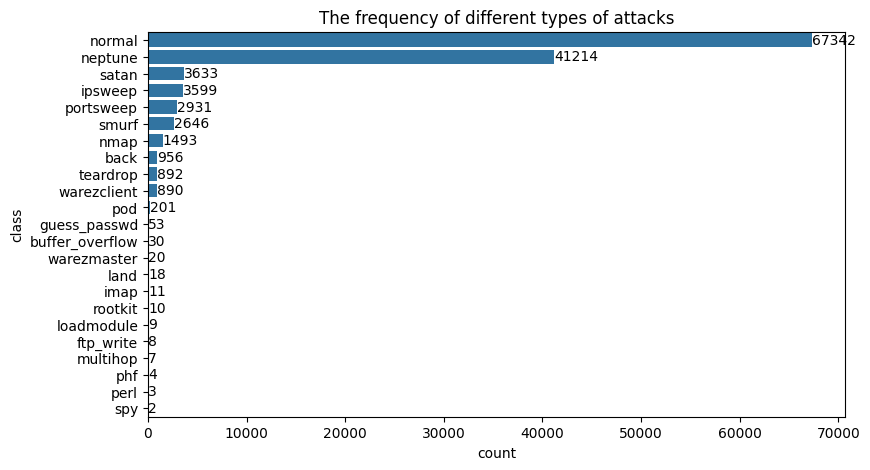

In [29]:
#Check frequency of attack class
fig = plt.figure(figsize=(9,5))
ax = sns.countplot(y=train_df['class'], data=train_df, order=train_df['class'].value_counts(ascending=False).index)
label = train_df['class'].value_counts(ascending=False).values
ax.bar_label(container=ax.containers[0], labels=label)
plt.title('The frequency of different types of attacks')
plt.show()

In [30]:
#Create a list to categorize types of attacks
dos_attacks = ['apache2','back','land','neptune','mailbomb','pod','processtable','smurf','teardrop','udpstorm','worm']
probe_attacks = ['ipsweep','mscan','nmap','portsweep','saint','satan']
privilege_attacks = ['buffer_overflow','loadmodule','perl','ps','rootkit','sqlattack','xterm']
access_attacks = ['ftp_write','guess_passwd','http_tunnel','imap','multihop','named','phf','sendmail','snmpgetattack','snmpguess','spy','warezclient','warezmaster','xclock','xsnoop']
#Create a dictionary
def segmentation(a):
    if a in dos_attacks:
        return 0
    elif a in probe_attacks:
        return 1
    elif a in privilege_attacks:
        return 2
    elif a in access_attacks:
        return 3        
    else: return np.nan
train_df['attack_type'] = train_df['class'].apply(segmentation)
test_df['attack_type'] = test_df['class'].apply(segmentation)

In [31]:
#Create attack flag
train_df['attack_flag'] = train_df['class'].apply(lambda x: 0 if x == 'normal' else 1)
test_df['attack_flag'] = test_df['class'].apply(lambda x: 0 if x == 'normal' else 1)
train_df['attack_flag'].value_counts()

attack_flag
0    67342
1    58630
Name: count, dtype: int64

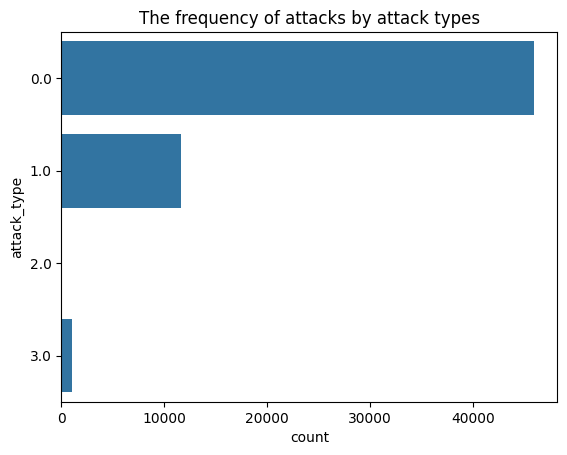

In [32]:
# Plot frequncy of attack types
sns.countplot(y=train_df['attack_type'])
plt.title('The frequency of attacks by attack types')
plt.show()

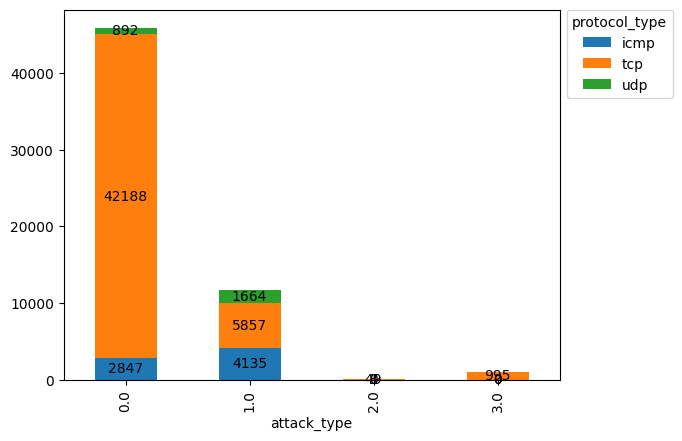

In [33]:
#Plot attack types by protocol types
attack_by_protocol = pd.crosstab(train_df['attack_type'],train_df['protocol_type'])
ax = attack_by_protocol.plot(kind='bar', stacked=True)
ax.legend(title='protocol_type', bbox_to_anchor=(1, 1.02), loc='upper left')
for c in ax.containers:
    ax.bar_label(c, label_type='center')

In [34]:
# Attack types by flags
pd.crosstab(train_df['attack_type'],train_df['flag'])

flag,OTH,REJ,RSTO,RSTOS0,RSTR,S0,S1,S2,S3,SF,SH
attack_type,,,,,,,,,,,
0.0,0,5671,1216,0,90,34344,2,5,0,4599,0
1.0,35,2869,80,103,2180,153,1,2,1,5967,265
2.0,0,0,1,0,0,0,0,0,0,51,0
3.0,0,0,46,0,5,0,1,1,3,935,4


In [35]:
# Drop noise in su_attempted
train_df.drop(train_df[train_df['su_attempted']==2].index)
test_df.drop(test_df[test_df['su_attempted']==2].index)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,level,attack_type,attack_flag
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.00,0.00,0.0,1.00,1.00,neptune,21,0.0,1
1,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.02,0.00,0.0,0.00,0.00,normal,21,NaN,0
2,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.28,0.00,0.0,0.00,0.00,saint,15,1.0,1
3,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.03,0.02,0.00,0.0,0.83,0.71,mscan,11,1.0,1
4,0,tcp,http,SF,267,14515,0,0,0,0,...,0.01,0.03,0.01,0.0,0.00,0.00,normal,21,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22538,0,tcp,smtp,SF,794,333,0,0,0,0,...,0.01,0.01,0.01,0.0,0.00,0.00,normal,21,NaN,0
22539,0,tcp,http,SF,317,938,0,0,0,0,...,0.01,0.01,0.01,0.0,0.00,0.00,normal,21,NaN,0
22540,0,tcp,http,SF,54540,8314,0,0,0,2,...,0.00,0.00,0.00,0.0,0.07,0.07,back,15,0.0,1
22541,0,udp,domain_u,SF,42,42,0,0,0,0,...,0.00,0.00,0.00,0.0,0.00,0.00,normal,21,NaN,0


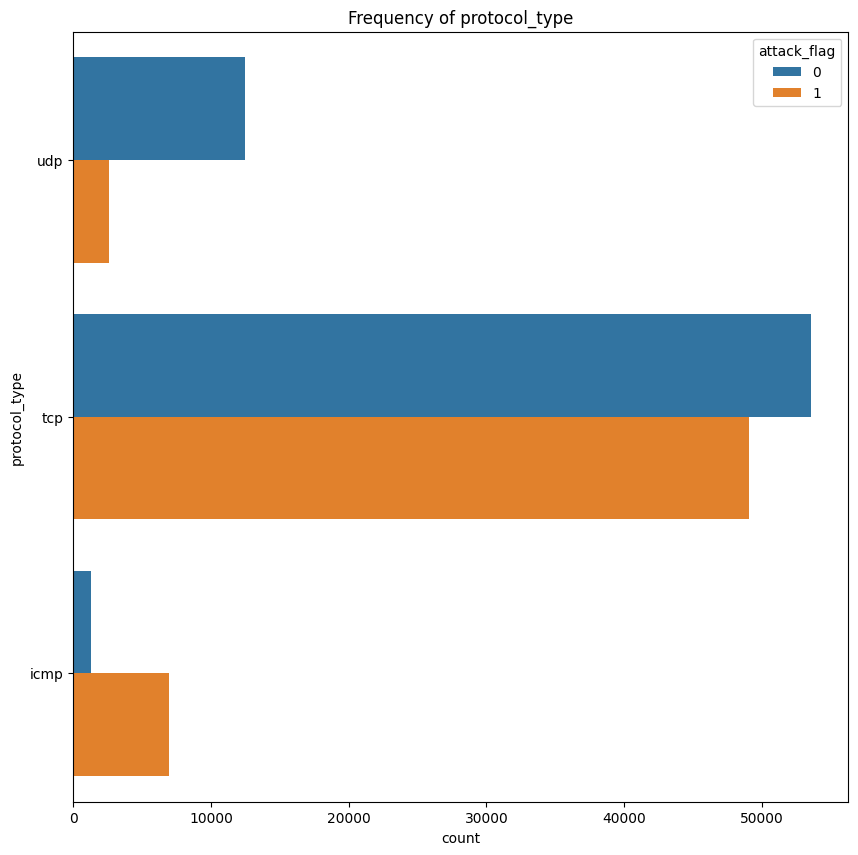

protocol_type
tcp     0.815165
udp     0.119019
icmp    0.065816
Name: proportion, dtype: float64


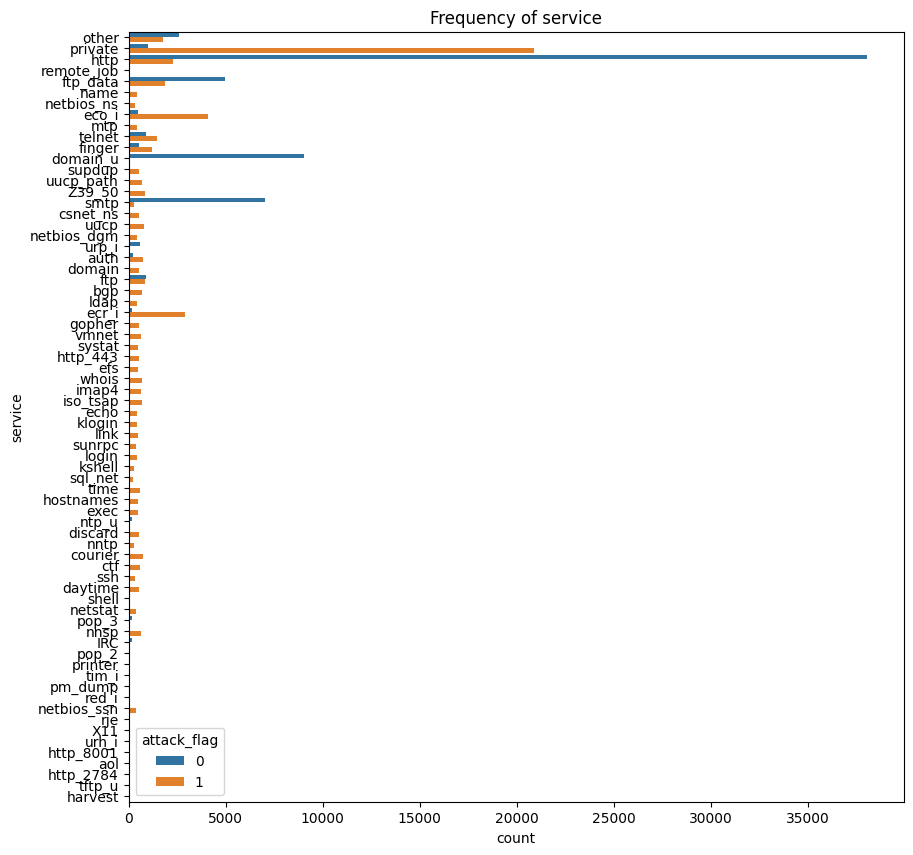

service
http         0.320214
private      0.173475
domain_u     0.071786
smtp         0.058053
ftp_data     0.054449
               ...   
tftp_u       0.000024
http_8001    0.000016
aol          0.000016
harvest      0.000016
http_2784    0.000008
Name: proportion, Length: 70, dtype: float64


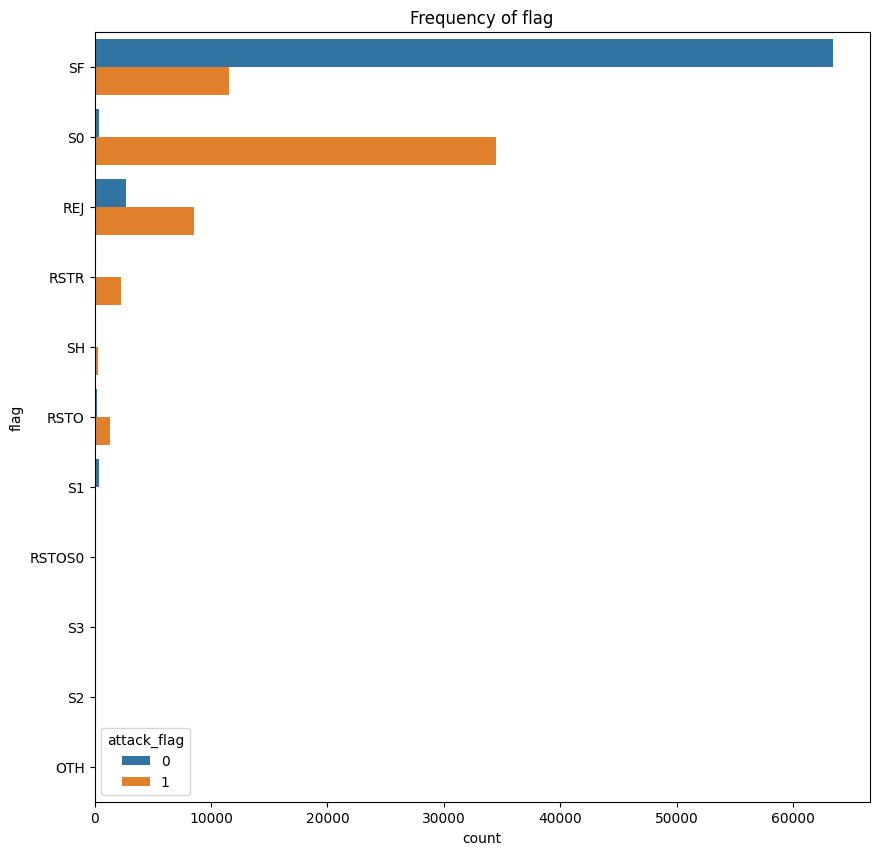

flag
SF        0.594926
S0        0.276657
REJ       0.089171
RSTR      0.019219
RSTO      0.012400
S1        0.002897
SH        0.002151
S2        0.001008
RSTOS0    0.000818
S3        0.000389
OTH       0.000365
Name: proportion, dtype: float64


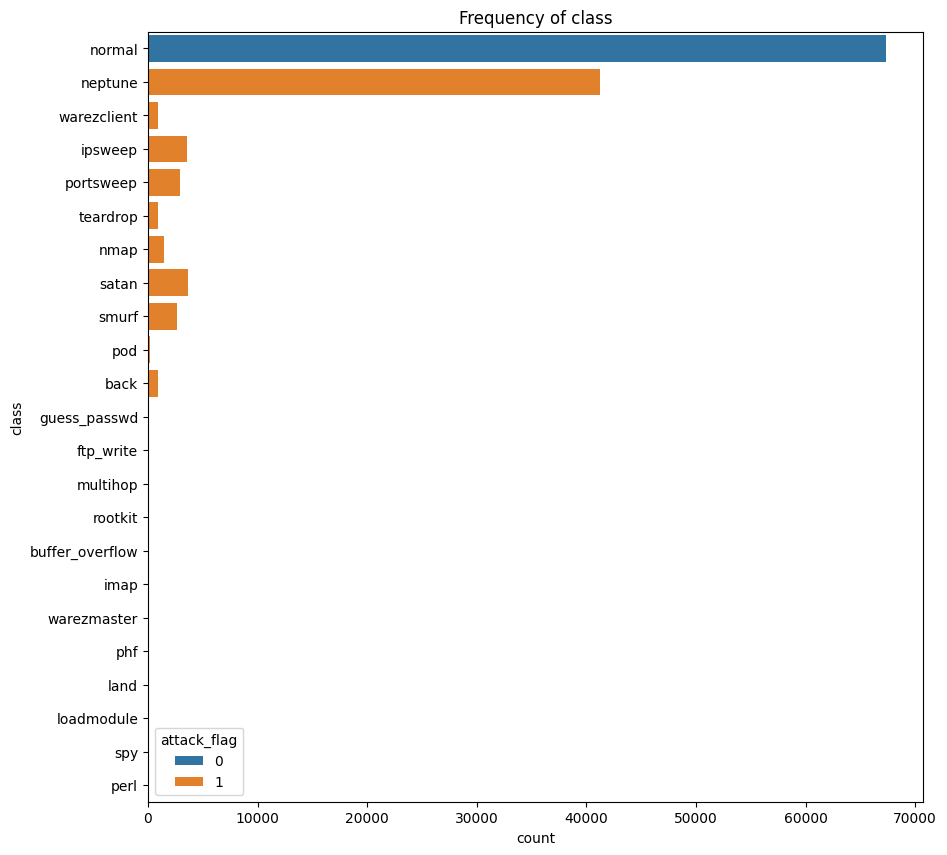

class
normal             0.534579
neptune            0.327168
satan              0.028840
ipsweep            0.028570
portsweep          0.023267
smurf              0.021005
nmap               0.011852
back               0.007589
teardrop           0.007081
warezclient        0.007065
pod                0.001596
guess_passwd       0.000421
buffer_overflow    0.000238
warezmaster        0.000159
land               0.000143
imap               0.000087
rootkit            0.000079
loadmodule         0.000071
ftp_write          0.000064
multihop           0.000056
phf                0.000032
perl               0.000024
spy                0.000016
Name: proportion, dtype: float64


In [36]:
# Plot frequncy of attack flags by categorial columns
for col in train_df.select_dtypes(include='object'):
    plt.figure(figsize=(10, 10))
    sns.countplot(data=train_df, y=col, hue='attack_flag')
    plt.title('Frequency of '+col)
    plt.show()
    print(train_df[col].value_counts(normalize=True))

<Axes: >

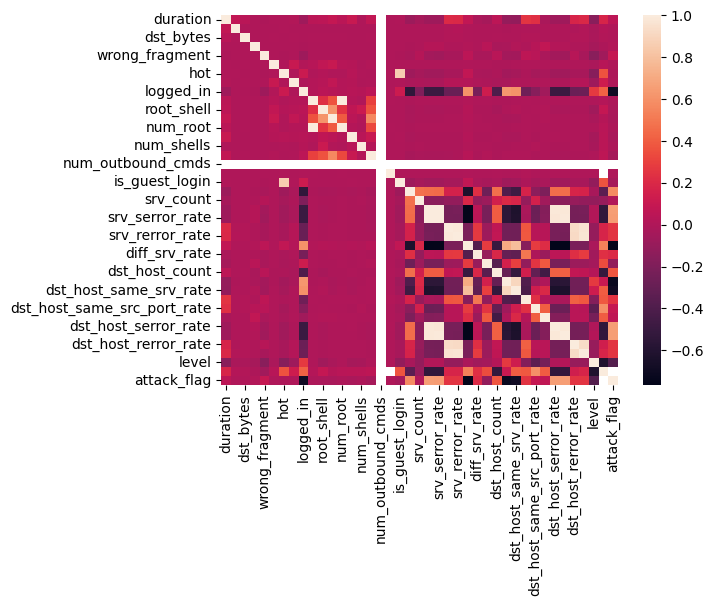

In [37]:
#Plot correlation
co = train_df.select_dtypes(exclude='object').corr()
sns.heatmap(co)

In [38]:
#Check unique values of num_outbound_cmds in train data
set(train_df['num_outbound_cmds'])

{0}

In [39]:
#Check unique values of num_outbound_cmds in test data
set(test_df['num_outbound_cmds'])

{0}

In [40]:
#Drop num_outbound_cmds
train_df = train_df.drop(columns=['num_outbound_cmds'])
test_df = test_df.drop(columns=['num_outbound_cmds'])

<Axes: >

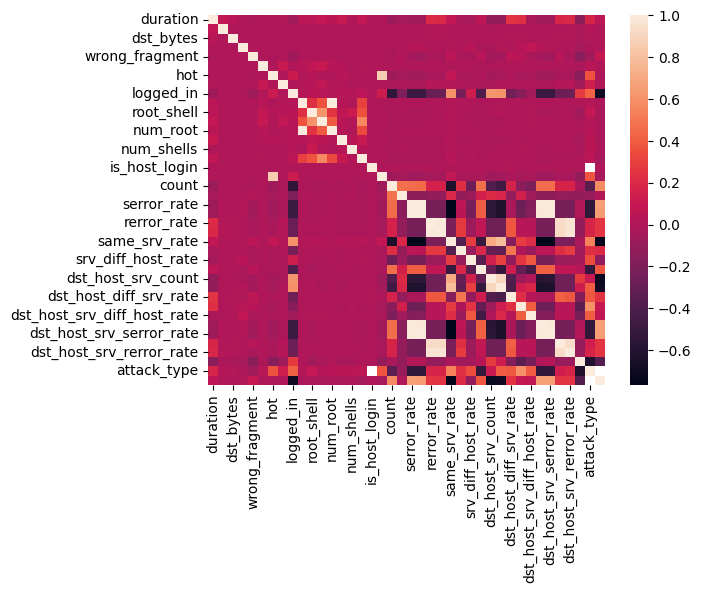

In [41]:
#Check correlation
co = train_df.select_dtypes(exclude='object').corr()
sns.heatmap(co)

In [42]:
#Check significant correlation betwwen attack_type and attack_flag with other features
co[abs(co['attack_type'])>=0.5][['attack_type','attack_flag']]

,attack_type,attack_flag
serror_rate,-0.532282,0.650651
srv_serror_rate,-0.530923,0.648287
same_srv_rate,0.532789,-0.751912
dst_host_count,-0.522454,0.375051
dst_host_same_src_port_rate,0.597550,0.092445
dst_host_serror_rate,-0.533253,0.651840
dst_host_srv_serror_rate,-0.528943,0.654984
level,-0.615129,-0.379707
attack_type,1.000000,NaN


In [43]:
#Drop class column
train_df = train_df.drop(columns=['class'], axis=1)
test_df = test_df.drop(columns=['class'], axis=1)

In [44]:
#Check columns for encoding
train_df.select_dtypes(include='object').columns

Index(['protocol_type', 'service', 'flag'], dtype='object')

In [45]:
#Label encoding
label_encoder = preprocessing.LabelEncoder()
for col in train_df.select_dtypes(include='object').columns:
    label_encoder = preprocessing.LabelEncoder()
    label_encoder.fit(train_df[col])
    train_df[col]= label_encoder.transform(train_df[col])
    test_df[col]= label_encoder.transform(test_df[col])

In [46]:
#Print first 5 rows
train_df.head().transpose()

,0,1,2,3,4
duration,0.00,0.00,0.00,0.00,0.00
protocol_type,2.00,1.00,1.00,1.00,1.00
service,44.00,49.00,24.00,24.00,49.00
flag,9.00,5.00,9.00,9.00,1.00
src_bytes,146.00,0.00,232.00,199.00,0.00
dst_bytes,0.00,0.00,8153.00,420.00,0.00
land,0.00,0.00,0.00,0.00,0.00
wrong_fragment,0.00,0.00,0.00,0.00,0.00
urgent,0.00,0.00,0.00,0.00,0.00
hot,0.00,0.00,0.00,0.00,0.00


# MULTIPLE CLASSIFICATION

In [47]:
# Frequncy of attack type
train_df['attack_type'].value_counts()

attack_type
0.0    45927
1.0    11656
3.0      995
2.0       52
Name: count, dtype: int64

In [48]:
train_df_1 = train_df[train_df['attack_type'].isnull() == False]
test_df_1 = test_df[test_df['attack_type'].isnull() == False]

In [49]:
#Split X and Y for 2 classifications
x_train = train_df_1.drop(columns=['attack_type', 'attack_flag'], axis=1)
y_train = train_df_1['attack_type']
x_test = test_df_1.drop(columns=['attack_type', 'attack_flag'], axis=1)
y_test = test_df_1['attack_type']

In [50]:
#Oversampling to deal with imbalanced dataset
oversample = SMOTE(random_state=42)
x_train, y_train = oversample.fit_resample(x_train, y_train)
y_train.value_counts()

attack_type
0.0    45927
3.0    45927
1.0    45927
2.0    45927
Name: count, dtype: int64

In [51]:
#Scaling
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

**LOGISTIC REGRESSION**

In [52]:
# Fitting data into Logistic Regression model
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)

In [53]:
#Classification report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.89      0.96      0.92      7459
         1.0       0.60      0.88      0.72      2421
         2.0       0.08      0.39      0.14        67
         3.0       0.88      0.26      0.40      2743

    accuracy                           0.79     12690
   macro avg       0.61      0.62      0.55     12690
weighted avg       0.83      0.79      0.77     12690



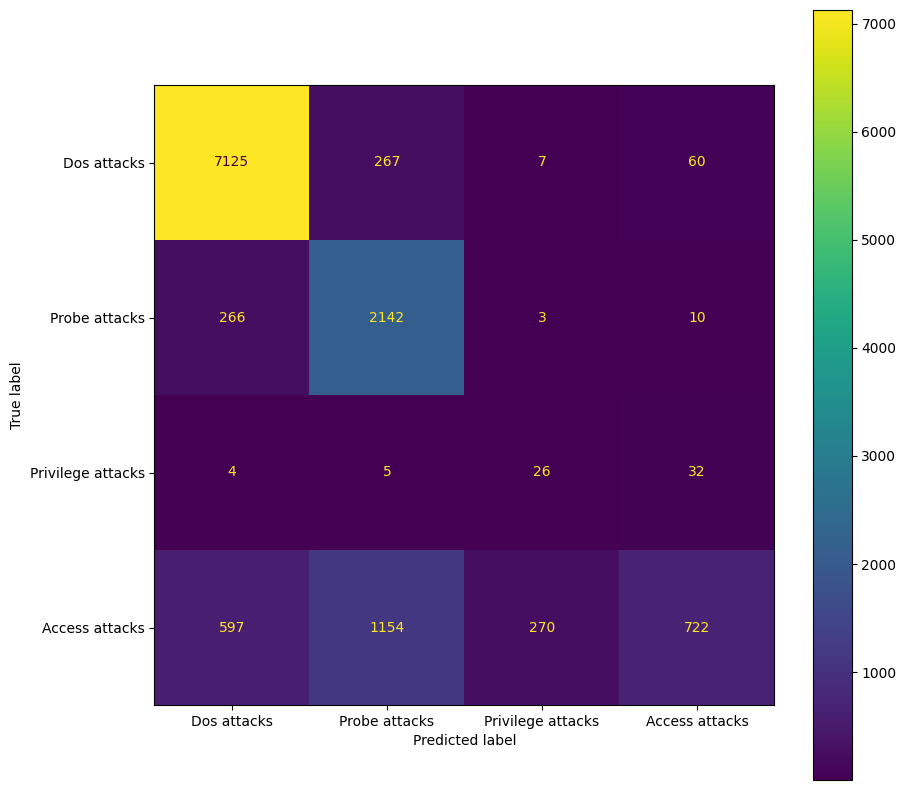

In [54]:
# Confusion matrix
att = ['Dos attacks', 'Probe attacks', 'Privilege attacks', 'Access attacks']
figure, ax = plt.subplots(figsize=(10,10))
cm = confusion_matrix(y_test, y_pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = att)
cm_display.plot(ax=ax)
plt.show()

In [55]:
#Create metrics table
Evaluation = pd.DataFrame(columns=['Accuracy','F1-Score','Precision','Recall'])
lr = [round(accuracy_score(y_test, y_pred)*100,2), 
      round(f1_score(y_test, y_pred, average='weighted')*100,2), 
      round(precision_score(y_test, y_pred, average='weighted')*100,2),
      round(recall_score(y_test, y_pred, average='weighted')*100,2)]
Evaluation.loc['Logistic Regression'] = lr

**Random Forest**

In [56]:
#Fitting data into Random Forest
rf = RandomForestClassifier()
rf.fit(x_train, y_train)
y_pred = rf.predict(x_test)

In [57]:
#Classification report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.95      0.89      0.92      7459
         1.0       0.61      0.93      0.74      2421
         2.0       0.36      0.40      0.38        67
         3.0       0.89      0.64      0.75      2743

    accuracy                           0.84     12690
   macro avg       0.70      0.72      0.70     12690
weighted avg       0.87      0.84      0.84     12690



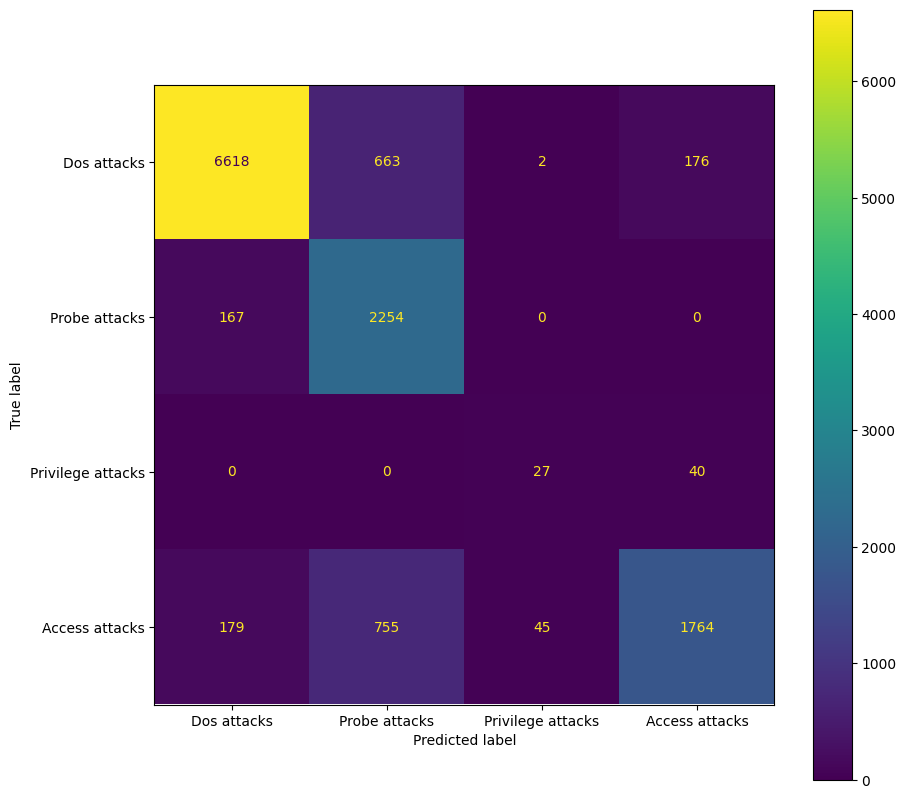

In [58]:
#Confusion matrix
figure, ax = plt.subplots(figsize=(10,10))
cm = confusion_matrix(y_test, y_pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = att)
cm_display.plot(ax=ax)
plt.show()

In [59]:
#Save metrics into metrics table
rf = [round(accuracy_score(y_test, y_pred)*100,2), 
      round(f1_score(y_test, y_pred, average='weighted')*100,2), 
      round(precision_score(y_test, y_pred, average='weighted')*100,2),
      round(recall_score(y_test, y_pred, average='weighted')*100,2)]
Evaluation.loc['Random Forest'] = rf

**XGBoost**

In [60]:
#Fitting data in XGBoost
xgboost = XGBClassifier()
xgboost.fit(x_train, y_train)
y_pred = xgboost.predict(x_test)

In [61]:
#Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.95      0.90      0.92      7459
         1.0       0.63      0.93      0.75      2421
         2.0       0.13      0.48      0.20        67
         3.0       0.95      0.62      0.75      2743

    accuracy                           0.84     12690
   macro avg       0.66      0.73      0.66     12690
weighted avg       0.88      0.84      0.85     12690



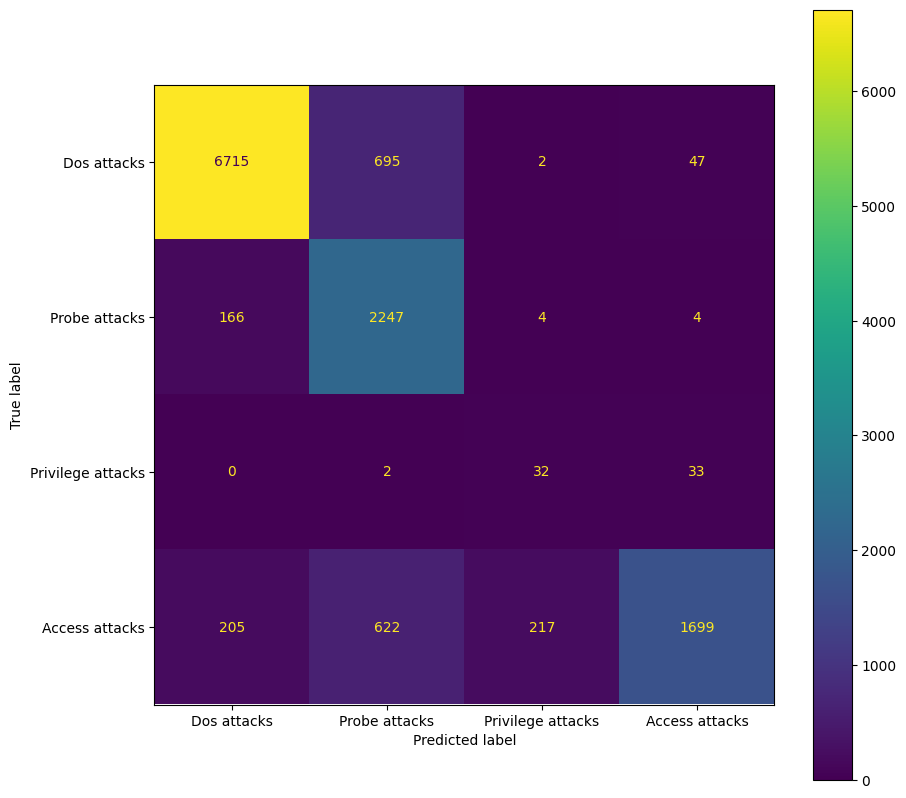

In [62]:
#Confusion matrix
figure, ax = plt.subplots(figsize=(10,10))
cm = confusion_matrix(y_test, y_pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = att)
cm_display.plot(ax=ax)
plt.show()

In [63]:
#Save metrics into metrics table
xg = [round(accuracy_score(y_test, y_pred)*100,2), 
      round(f1_score(y_test, y_pred, average='weighted')*100,2), 
      round(precision_score(y_test, y_pred, average='weighted')*100,2),
      round(recall_score(y_test, y_pred, average='weighted')*100,2)]
Evaluation.loc['XGBoost'] = xg

In [64]:
#Print metrics table
Evaluation

,Accuracy,F1-Score,Precision,Recall
Logistic Regression,78.92,76.68,82.84,78.92
Random Forest,84.03,84.40,87.02,84.03
XGBoost,84.26,84.93,88.39,84.26


# BINARY CLASSIFICATION

In [65]:
#Split X and Y
x_train_2 = train_df.drop(columns=['attack_type', 'attack_flag'], axis=1)
y_train_2 = train_df['attack_flag']
x_test_2 = test_df.drop(columns=['attack_type', 'attack_flag'], axis=1)
y_test_2 = test_df['attack_flag']

In [66]:
x_train_2.shape

(125972, 41)

In [67]:
#Check frequency of attack flag
y_train_2.value_counts()

attack_flag
0    67342
1    58630
Name: count, dtype: int64

In [68]:
#Scaling
sc = StandardScaler()
x_train_2 = sc.fit_transform(x_train_2)
x_test_2 = sc.transform(x_test_2)

**Logistic Regression**

In [69]:
# Fitting data into Logistic Regression model
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train_2,y_train_2)
y_pred_2 = lr.predict(x_test_2)

In [70]:
#Classification report
print(classification_report(y_test_2, y_pred_2))

              precision    recall  f1-score   support

           0       0.76      0.92      0.83      9711
           1       0.93      0.78      0.85     12832

    accuracy                           0.84     22543
   macro avg       0.85      0.85      0.84     22543
weighted avg       0.86      0.84      0.84     22543



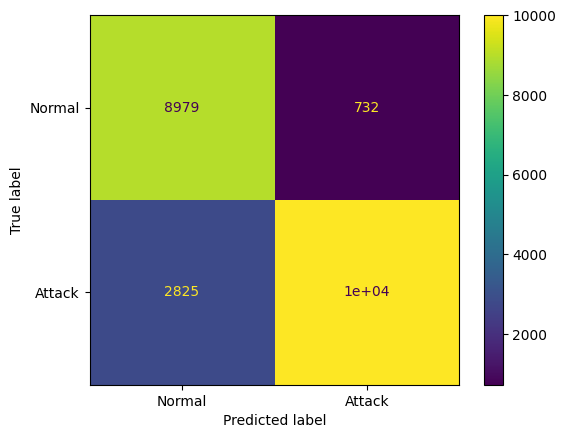

In [71]:
#Confusion matrix
cm = confusion_matrix(y_test_2, y_pred_2)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['Normal', 'Attack'])
cm_display.plot()
plt.show()

In [72]:
#Create metrics table and save metrics into this table
Evaluation_1 = pd.DataFrame(columns=['Accuracy','F1-Score','Precision','Recall'])
lr = [round(accuracy_score(y_test_2, y_pred_2)*100,2), 
      round(f1_score(y_test_2, y_pred_2)*100,2), 
      round(precision_score(y_test_2, y_pred_2)*100,2),
      round(recall_score(y_test_2, y_pred_2)*100,2)]
Evaluation_1.loc['Logistic Regression'] = lr

**Linear SVC**

In [73]:
#Fitting data into Linear SVC
svc = LinearSVC()
svc.fit(x_train_2, y_train_2)
y_pred_2 = svc.predict(x_test_2)

In [74]:
#Classification report
print(classification_report(y_test_2, y_pred_2))

              precision    recall  f1-score   support

           0       0.77      0.93      0.84      9711
           1       0.93      0.79      0.85     12832

    accuracy                           0.85     22543
   macro avg       0.85      0.86      0.85     22543
weighted avg       0.86      0.85      0.85     22543



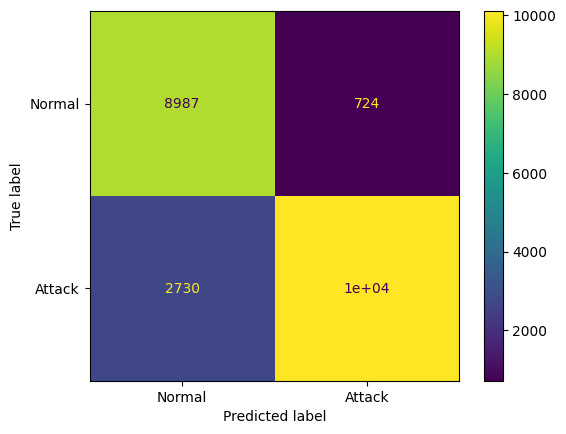

In [75]:
#Confusion matrix
cm = confusion_matrix(y_test_2, y_pred_2)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['Normal', 'Attack'])
cm_display.plot()
plt.show()

In [76]:
#Save metrics into metrics table
lisvc = [round(accuracy_score(y_test_2, y_pred_2)*100,2), 
      round(f1_score(y_test_2, y_pred_2)*100,2), 
      round(precision_score(y_test_2, y_pred_2)*100,2),
      round(recall_score(y_test_2, y_pred_2)*100,2)]
Evaluation_1.loc['Linear SVC'] = lisvc

**Poly SVC**

In [77]:
#Fitting data into Poly SVC
svc_poly = SVC(kernel = 'poly')
svc_poly.fit(x_train_2, y_train_2)
y_pred_2 = svc_poly.predict(x_test_2)

In [78]:
#Classification report
print(classification_report(y_test_2, y_pred_2))

              precision    recall  f1-score   support

           0       0.74      0.96      0.84      9711
           1       0.96      0.75      0.84     12832

    accuracy                           0.84     22543
   macro avg       0.85      0.86      0.84     22543
weighted avg       0.87      0.84      0.84     22543



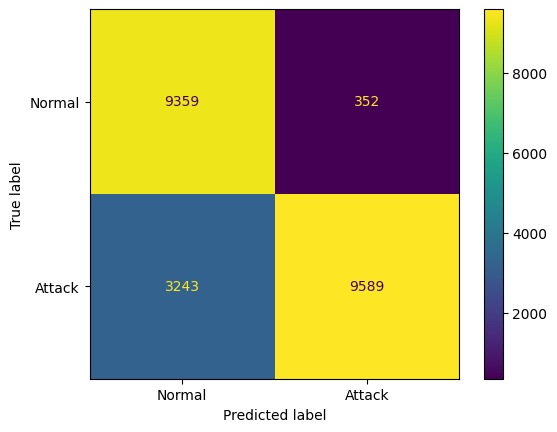

In [79]:
#Confusion matrix
cm = confusion_matrix(y_test_2, y_pred_2)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['Normal', 'Attack'])
cm_display.plot()
plt.show()

In [80]:
#Save metrics into metrics table
polysvc = [round(accuracy_score(y_test_2, y_pred_2)*100,2), 
      round(f1_score(y_test_2, y_pred_2)*100,2), 
      round(precision_score(y_test_2, y_pred_2)*100,2),
      round(recall_score(y_test_2, y_pred_2)*100,2)]
Evaluation_1.loc['Poly SVC'] = polysvc

**Random Forest**

In [81]:
#Fitting data into Random Forest
rf = RandomForestClassifier()
rf.fit(x_train_2, y_train_2)
y_pred_2 = rf.predict(x_test_2)

In [82]:
#Classification report
print(classification_report(y_test_2, y_pred_2))

              precision    recall  f1-score   support

           0       0.71      0.97      0.82      9711
           1       0.97      0.70      0.82     12832

    accuracy                           0.82     22543
   macro avg       0.84      0.84      0.82     22543
weighted avg       0.86      0.82      0.82     22543



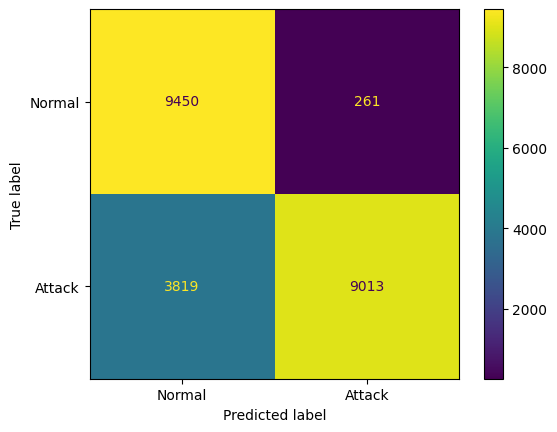

In [83]:
#Confusion matrix
cm = confusion_matrix(y_test_2, y_pred_2)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['Normal', 'Attack'])
cm_display.plot()
plt.show()

In [84]:
#Save metrics into metrics table
rf = [round(accuracy_score(y_test_2, y_pred_2)*100,2), 
      round(f1_score(y_test_2, y_pred_2)*100,2), 
      round(precision_score(y_test_2, y_pred_2)*100,2),
      round(recall_score(y_test_2, y_pred_2)*100,2)]
Evaluation_1.loc['Random Forest'] = rf

In [85]:
#Print metrics table
Evaluation_1

,Accuracy,F1-Score,Precision,Recall
Logistic Regression,84.22,84.91,93.18,77.98
Linear SVC,84.68,85.40,93.31,78.73
Poly SVC,84.05,84.21,96.46,74.73
Random Forest,81.90,81.54,97.19,70.24


In [89]:
import joblib
joblib.dump(svc,'binary_classification.joblib')

['binary_classification.joblib']

In [90]:
joblib.dump(xgboost, 'multiclass_classification.joblib')

['multiclass_classification.joblib']